**To perform Exploratory Data Analysis (EDA) and data preprocessing in Python using Pandas, including data cleaning, handling missing values, normalization, and encoding for analytics.**



A dataset is a collection of data used for analysis and machine learning. All datasets in the real world can be categorized into three main types:
**structured, unstructured, and semi-structured.**

---


Structured datasets are arranged in rows and columns like tables, making them easy to analyze—for example CSV, Excel, and SQL databases.

---


Unstructured datasets have no fixed format and include data such as images, videos, audio, and text, which require advanced preprocessing to extract useful information.

---


Semi-structured datasets are not fully tabular but contain some organizational structure such as tags or key-value pairs—common examples include JSON, XML, and log files.

---


Therefore, regardless of format, every dataset belongs to one of these three core types.

```
What is a CSV Dataset?
```




A CSV (**Comma Separated Values**) dataset is a type of structured dataset where data is organized in rows and columns.

Each row represents a data record (sample).

Each column represents a feature (attribute).

Values are separated by commas.


***Steps for CSV Data Analysis & Preprocessing***

Step 1: Load Dataset

Step 2: Exploratory Data Analysis (EDA)

Step 3: Data Preprocessing


1. Identify Missing Values
    - Check NaN / Null values in columns
    
2. Handle Missing Values
    - Fill using Mean / Median / Mode
    - OR Drop rows / columns if needed

3. Detect Duplicate Records
    - Identify duplicate rows

4. Remove Duplicates
    - Drop duplicate entries

5. Detect Outliers
    - Use statistical methods (IQR / Z-score)

6. Handle Outliers
    - Remove or cap values (Winsorization)

7. Separate Numerical & Categorical Data
    - Identify column types for processing

8. Encode Categorical Features
    - Label Encoding / One-Hot Encoding / Ordinal Encoding

9. Scale Numerical Data
    - Normalization (min-max)
    - Standardization (Z-score)

10. Handle Imbalanced Dataset (if any)
    - Oversampling, Undersampling, SMOTE

11. Feature Selection / Drop Irrelevant Features
    - Remove columns like "ID", "Ticket no", etc.

12. Train-Test Split
    - Split into training and testing sets

13. Save Cleaned Dataset
    - Export processed data for ML model


In [ ]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt #Basic data visualization library. Used for plotting histograms, bar plots, line plots, etc.
import seaborn as sns #Advanced visualization library based on Matplotlib. Helps create heatmaps, countplots, boxplots, and correlation plots with less code.

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [ ]:
# Step 1: Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [ ]:
print("\nLast 5 rows:")
print(df.tail())


Last 5 rows:
     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [ ]:
print("\nDataset shape:", df.shape)


Dataset shape: (891, 12)


In [ ]:
print("\nColumn names:", df.columns.tolist())


Column names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [ ]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [ ]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [ ]:
print("\nUnique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")


Unique values per column:
PassengerId: 891
Survived: 2
Pclass: 3
Name: 891
Sex: 2
Age: 88
SibSp: 7
Parch: 7
Ticket: 681
Fare: 248
Cabin: 147
Embarked: 3


In [ ]:
#print("\nCorrelation matrix:") #for numeric features only
# print(df.corr())

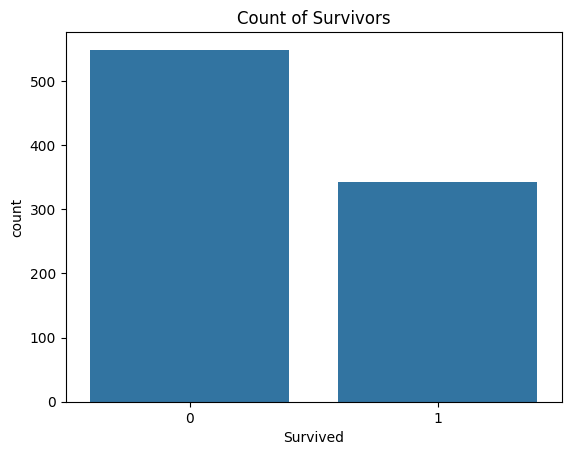

In [ ]:
sns.countplot(x='Survived', data=df)
plt.title("Count of Survivors")
plt.show()

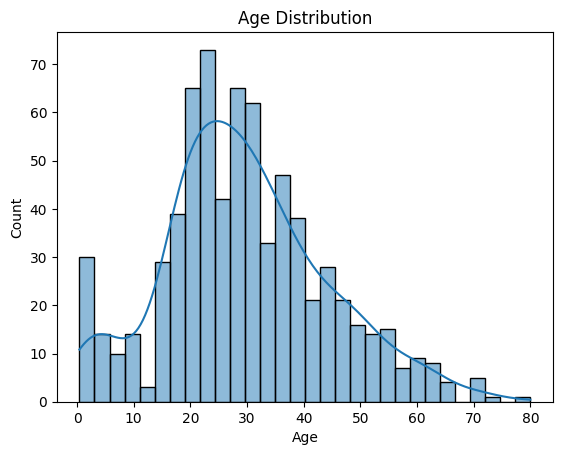

In [ ]:
sns.histplot(df['Age'], bins=30, kde=True)  # Kernel Density Estimate is a smoothed curve. it shows how data is distributed in a continuous way, rather than just counts per bin like a histogram.
plt.title('Age Distribution')
plt.show()

In [ ]:
# Step 6: Drop Irrelevant Columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
print("\nDropped irrelevant columns.")


Dropped irrelevant columns.


In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
# Step 7: Handle Missing Values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
print("\nHandled missing values.")


Handled missing values.


/tmp/ipython-input-465075740.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-465075740.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,28.0,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [ ]:
# Step 8: Encode Categorical Variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])        # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked']) # C=0, Q=1, S=2
print("\nEncoded categorical columns.")


Encoded categorical columns.


In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,2
887,1,1,0,19.0,0,0,30.0000,2
888,0,3,0,28.0,1,2,23.4500,2
889,1,1,1,26.0,0,0,30.0000,0


In [ ]:
# Step 9: Scale Numeric Features
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])
print("\nScaled numeric features.")


Scaled numeric features.


In [ ]:
#from sklearn.preprocessing import MinMaxScaler
#scaler_mm = MinMaxScaler()
#df[numeric_features] = scaler_mm.fit_transform(df[numeric_features])

#print("After Min-Max Scaling (0-1 normalization):")
#print(df[numeric_features].head())

In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,2
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,0
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,2
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,2
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,2
...,...,...,...,...,...,...,...,...
886,0,2,1,-0.181487,-0.474545,-0.473674,-0.386671,2
887,1,1,0,-0.796286,-0.474545,-0.473674,-0.044381,2
888,0,3,0,-0.104637,0.432793,2.008933,-0.176263,2
889,1,1,1,-0.258337,-0.474545,-0.473674,-0.044381,0


In [ ]:
# Step 10: Check Final Dataset
print("\nProcessed dataset info:")
print(df.info())
print(df.head())


Processed dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    float64
 5   Parch     891 non-null    float64
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(4), int64(4)
memory usage: 55.8 KB
None
   Survived  Pclass  Sex       Age     SibSp     Parch      Fare  Embarked
0         0       3    1 -0.565736  0.432793 -0.473674 -0.502445         2
1         1       1    0  0.663861  0.432793 -0.473674  0.786845         0
2         1       3    0 -0.258337 -0.474545 -0.473674 -0.488854         2
3         1       1    0  0.433312  0.432793 -0.473674  0.420730         2
4         0       3    1  0.433312 -0.474545 -0.47

In [ ]:
# Step 11: Split Dataset into Train/Test
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("\nTrain/Test split done.")


Train/Test split done.


In [ ]:
print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

X_train shape: (712, 7) X_test shape: (179, 7)


In [ ]:
# Step 12: Save Processed Dataset
df.to_csv("titanic_processed.csv", index=False)
print("\nProcessed dataset saved as 'titanic_processed.csv'")


Processed dataset saved as 'titanic_processed.csv'


**Image dataset**

1. Read any inbuilt image dataset. (RGB image)
2. Print size and shape of the dataset as well as the single image.
3. Display one of the sample images. side by side (It's three channels), and pixel values also.
4. Convert the image from RGB to grey and have a pixel value side by side.
5. Normalize the image or scale it and take a look at the result
6. Data augmentation on the image.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# 1. Read any inbuilt image dataset.(RGB image)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset loaded successfully


In [ ]:
# 2. Print size and shape of dataset as well as single image
print("\nDataset Information:")
print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Single image shape    :", x_train[0].shape)


Dataset Information:
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Single image shape    : (32, 32, 3)


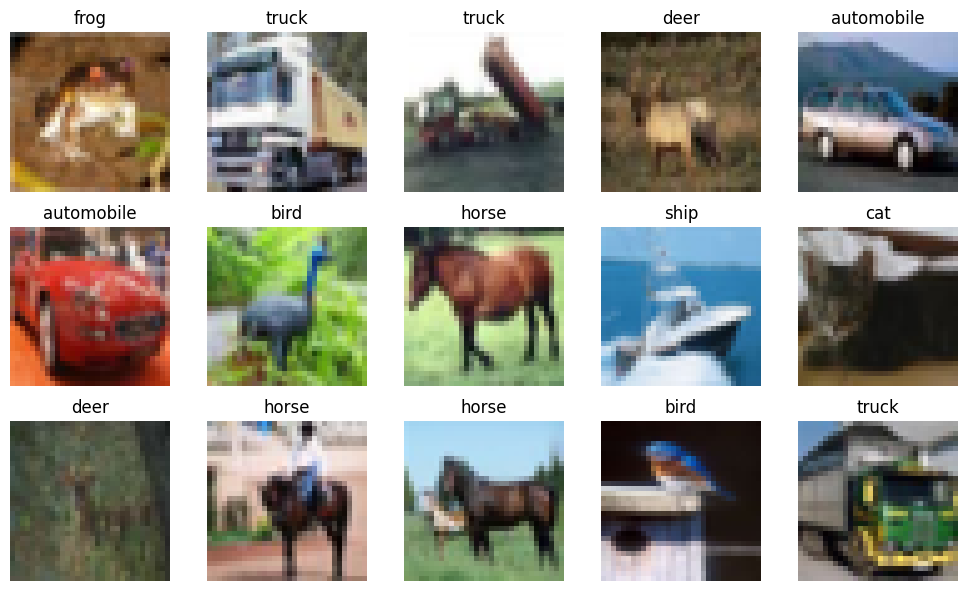

In [ ]:
# Class_names are not mentiond in the dataset so we are explicitly mentioning it.

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
axes = axes.ravel()

for i in range(15):
    axes[i].imshow(x_train[i])
    axes[i].set_title(class_names[y_train[i][0]])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

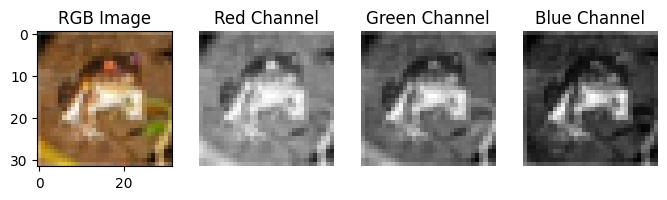

In [ ]:
# 3. Select one sample image and display
img_rgb = x_train[0]

plt.figure(figsize=(8, 4))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("RGB Image")
plt.axis("on")

plt.subplot(1, 4, 2)
plt.imshow(img_rgb[:, :, 0], cmap="gray")
plt.title("Red Channel")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_rgb[:, :, 1], cmap="gray")
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_rgb[:, :, 2], cmap="gray")
plt.title("Blue Channel")
plt.axis("off")

plt.show()

In [ ]:
# Print pixel values of a small region
print("\nRGB Pixel Values (Top-left 5x5 pixels):")
print(img_rgb[0:5, 0:5, :])


RGB Pixel Values (Top-left 5x5 pixels):
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  [ 68  54  42]
  [ 98  73  52]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  [ 51  27   8]
  [ 88  51  21]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  [ 83  50  23]
  [110  72  41]]

 [[ 33  25  17]
  [ 38  20   4]
  [ 87  54  25]
  [106  63  28]
  [115  70  33]]

 [[ 50  32  21]
  [ 59  32  11]
  [102  65  34]
  [127  79  39]
  [124  77  36]]]


[159 102 101]
| Channel   | Value | Meaning            |
| --------- | ----- | ------------------ |
| Red (R)   | 159   | Intensity of red   |
| Green (G) | 102   | Intensity of green |
| Blue (B)  | 101   | Intensity of blue  |

Row 0, Column 0 → [159 102 101]
Row 0, Column 1 → [150  91  95]
Row 1, Column 0 → [142  75  68]


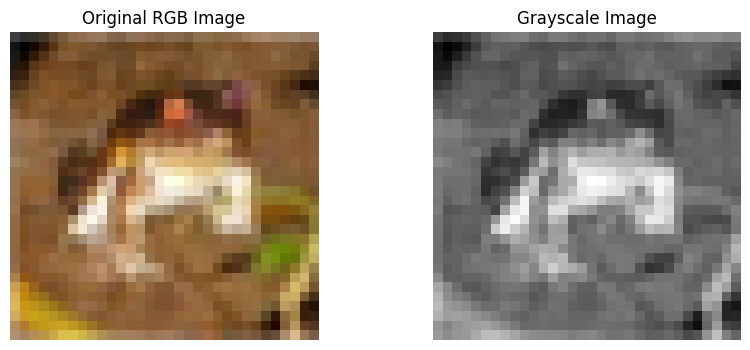


RGB Pixel Values (Top-left 4x5 pixels):
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  [ 68  54  42]
  [ 98  73  52]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  [ 51  27   8]
  [ 88  51  21]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  [ 83  50  23]
  [110  72  41]]

 [[ 33  25  17]
  [ 38  20   4]
  [ 87  54  25]
  [106  63  28]
  [115  70  33]]]

Grayscale Pixel Values (Top-left 4x5 pixels):
[[61 45 48 57 78]
 [19  0 10 32 59]
 [24  9 31 57 80]
 [26 24 61 72 79]]


In [ ]:
# Conver the image from RGB to gray and have a pixel value side by side.

img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

print("\nRGB Pixel Values (Top-left 4x5 pixels):")
print(img_rgb[0:4, 0:5])

print("\nGrayscale Pixel Values (Top-left 4x5 pixels):")
print(img_gray[0:4, 0:5])

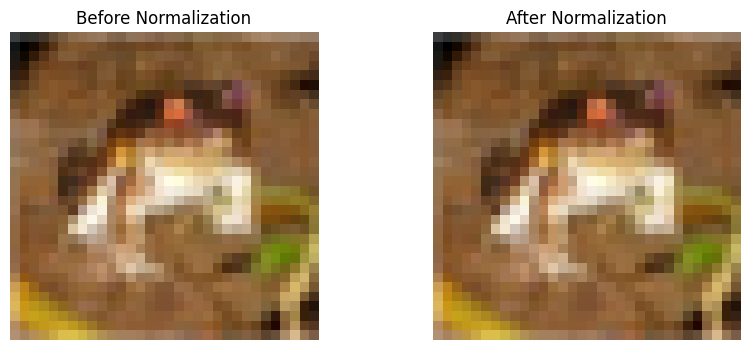


RGB Pixel Values (Top-left 4x5 pixels):
[[[ 59  62  63]
  [ 43  46  45]
  [ 50  48  43]
  [ 68  54  42]
  [ 98  73  52]]

 [[ 16  20  20]
  [  0   0   0]
  [ 18   8   0]
  [ 51  27   8]
  [ 88  51  21]]

 [[ 25  24  21]
  [ 16   7   0]
  [ 49  27   8]
  [ 83  50  23]
  [110  72  41]]

 [[ 33  25  17]
  [ 38  20   4]
  [ 87  54  25]
  [106  63  28]
  [115  70  33]]]

 Normalized image Pixel Values (Top-left 4x5 pixels):
[[[0.23137255 0.24313725 0.24705882]
  [0.16862745 0.18039216 0.17647059]
  [0.19607843 0.18823529 0.16862745]
  [0.26666667 0.21176471 0.16470588]
  [0.38431373 0.28627451 0.20392157]]

 [[0.0627451  0.07843137 0.07843137]
  [0.         0.         0.        ]
  [0.07058824 0.03137255 0.        ]
  [0.2        0.10588235 0.03137255]
  [0.34509804 0.2        0.08235294]]

 [[0.09803922 0.09411765 0.08235294]
  [0.0627451  0.02745098 0.        ]
  [0.19215686 0.10588235 0.03137255]
  [0.3254902  0.19607843 0.09019608]
  [0.43137255 0.28235294 0.16078431]]

 [[0.12941176 0

In [ ]:
# Normalize the image/scale the image and have a look at the result.

img_normalized = img_rgb / 255.0

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Before Normalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_normalized)
plt.title("After Normalization")
plt.axis("off")

plt.show()

print("\nRGB Pixel Values (Top-left 4x5 pixels):")
print(img_rgb[0:4, 0:5])

print("\n Normalized image Pixel Values (Top-left 4x5 pixels):")
print(img_normalized[0:4, 0:5])

print("\nPixel value range:")
print("Before normalization :", img_rgb.min(), "to", img_rgb.max())
print("After normalization  :", img_normalized.min(), "to", img_normalized.max())



Orignal image shape (32, 32, 3)
Expanded image shape (1, 32, 32, 3)


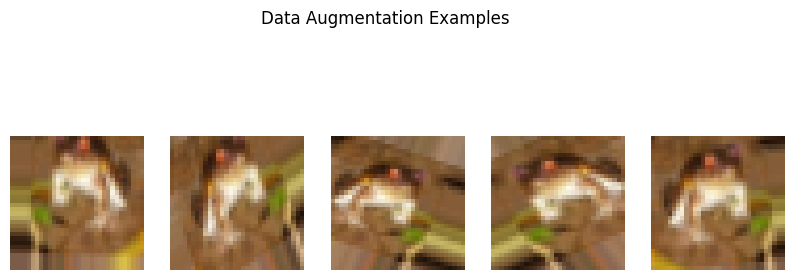

In [ ]:
# 6. Data augmentation

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

print("Orignal image shape",img_rgb.shape)

# Keras does not process single images directly for augmentation or training. It expects input in the form: (batch_size, height, width, channels)
# Even if you have only one image, it must still be wrapped inside a batch.
# Expand dimensions for augmentation (1, H, W, C)
img_expanded = np.expand_dims(img_rgb, axis=0)
print("Expanded image shape",img_expanded.shape)

# Generate augmented images. ImageDataGenerator.flow() requires 4D input:
augmented_images = datagen.flow(img_expanded, batch_size=1)

plt.figure(figsize=(10, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    augmented_img = next(augmented_images)[0].astype("uint8")
    plt.imshow(augmented_img)
    plt.axis("off")

plt.suptitle("Data Augmentation Examples")
plt.show()

# #### Extra


*   Load Digit dataset
*   Listout the dataset from sklearn.datasets
*   categorise the dataset according to it's type





In [ ]:
from sklearn.datasets import load_digits
digits = load_digits()

print(digits.keys())
# digits.images contains the raw image data (8*8)
# digits.data - The flattened version of images (length 64 arrays), used for training models.
# digits.target -  The actual number (0-9) that the image represents

# Check the shape of the raw images (for humans/plotting)

print("Image Data Shape:", digits.images.shape)

# Check the shape of the flattened data (for the ML model)
print("Flattened Data Shape:", digits.data.shape)

# Check the labels
print("Target Data Shape:", digits.target.shape)

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
Image Data Shape: (1797, 8, 8)
Flattened Data Shape: (1797, 64)
Target Data Shape: (1797,)


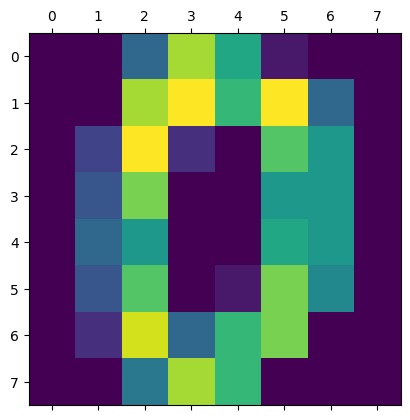

Target Label: 0


In [ ]:
import matplotlib.pyplot as plt

# Let's look at the first image (index 0)
#plt.gray() # Set colormap to grayscale
plt.matshow(digits.images[0]) # Display the image
plt.show()

# Print the label for this image
print("Target Label:", digits.target[0])

In [ ]:
import sklearn.datasets

# Get all attributes of the library
all_names = dir(sklearn.datasets)

# Filter by the three standard prefixes
loaders = [name for name in all_names if name.startswith("load_")]
fetchers = [name for name in all_names if name.startswith("fetch_")]
makers = [name for name in all_names if name.startswith("make_")]

print("--- BUILT-IN (Toy) DATASETS ---")
for name in loaders: print(name)

print("\n--- DOWNLOADABLE (Real-world) DATASETS ---")
for name in fetchers: print(name)

print("\n--- GENERATORS (Synthetic) ---")
for name in makers: print(name)

--- BUILT-IN (Toy) DATASETS ---
load_breast_cancer
load_diabetes
load_digits
load_files
load_iris
load_linnerud
load_sample_image
load_sample_images
load_svmlight_file
load_svmlight_files
load_wine

--- DOWNLOADABLE (Real-world) DATASETS ---
fetch_20newsgroups
fetch_20newsgroups_vectorized
fetch_california_housing
fetch_covtype
fetch_file
fetch_kddcup99
fetch_lfw_pairs
fetch_lfw_people
fetch_olivetti_faces
fetch_openml
fetch_rcv1
fetch_species_distributions

--- GENERATORS (Synthetic) ---
make_biclusters
make_blobs
make_checkerboard
make_circles
make_classification
make_friedman1
make_friedman2
make_friedman3
make_gaussian_quantiles
make_hastie_10_2
make_low_rank_matrix
make_moons
make_multilabel_classification
make_regression
make_s_curve
make_sparse_coded_signal
make_sparse_spd_matrix
make_sparse_uncorrelated
make_spd_matrix
make_swiss_roll


In [ ]:
import sklearn.datasets
import inspect

def classify_dataset_type(func_name):
    """
    Heuristics to classify sklearn datasets based on their names.
    """
    # 1. Image Datasets
    if any(x in func_name for x in ['faces', 'digits', 'lfw', 'olivetti', 'sample_images']):
        return "IMAGE"

    # 2. Text Datasets
    elif any(x in func_name for x in ['newsgroups', 'rcv1']):
        return "TEXT"

    # 3. Synthetic Generators (make_...)
    elif func_name.startswith('make_'):
        return "SYNTHETIC / GENERATOR"

    # 4. Tabular / Structured Data (The rest)
    # Most standard load_X functions are tabular (Iris, Diabetes, etc.)
    elif func_name.startswith('load_') or func_name.startswith('fetch_'):
        return "TABULAR / STRUCTURED"

    return "OTHER"

# Get all functions from sklearn.datasets
all_funcs = dir(sklearn.datasets)
dataset_funcs = [f for f in all_funcs if f.startswith(('load_', 'fetch_', 'make_'))]

# Create Dictionary to hold lists
categories = {
    "IMAGE": [],
    "TEXT": [],
    "TABULAR / STRUCTURED": [],
    "SYNTHETIC / GENERATOR": []
}

# Sort them
for func in dataset_funcs:
    cat = classify_dataset_type(func)
    if cat in categories:
        categories[cat].append(func)

# Print the results nicely
for category, funcs in categories.items():
    print(f"\n=== {category} DATASETS ({len(funcs)}) ===")
    for f in funcs:
        print(f"  - {f}")


=== IMAGE DATASETS (5) ===
  - fetch_lfw_pairs
  - fetch_lfw_people
  - fetch_olivetti_faces
  - load_digits
  - load_sample_images

=== TEXT DATASETS (3) ===
  - fetch_20newsgroups
  - fetch_20newsgroups_vectorized
  - fetch_rcv1

=== TABULAR / STRUCTURED DATASETS (15) ===
  - fetch_california_housing
  - fetch_covtype
  - fetch_file
  - fetch_kddcup99
  - fetch_openml
  - fetch_species_distributions
  - load_breast_cancer
  - load_diabetes
  - load_files
  - load_iris
  - load_linnerud
  - load_sample_image
  - load_svmlight_file
  - load_svmlight_files
  - load_wine

=== SYNTHETIC / GENERATOR DATASETS (20) ===
  - make_biclusters
  - make_blobs
  - make_checkerboard
  - make_circles
  - make_classification
  - make_friedman1
  - make_friedman2
  - make_friedman3
  - make_gaussian_quantiles
  - make_hastie_10_2
  - make_low_rank_matrix
  - make_moons
  - make_multilabel_classification
  - make_regression
  - make_s_curve
  - make_sparse_coded_signal
  - make_sparse_spd_matrix
  - ma

Shape: (427, 640, 3)


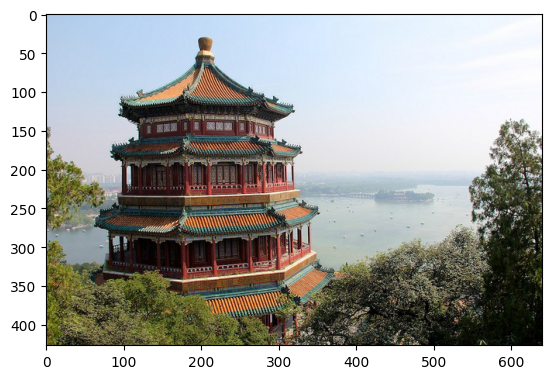

In [ ]:
from sklearn.datasets import load_sample_images
import matplotlib.pyplot as plt

dataset = load_sample_images()
first_image = dataset.images[0]

print("Shape:", first_image.shape)

plt.imshow(first_image)
plt.show()

Shape: (427, 640, 3)


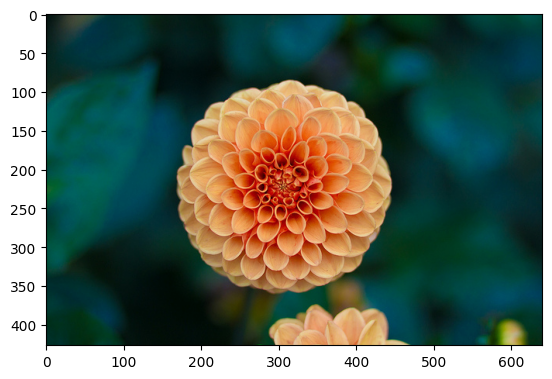

In [ ]:
second_image = dataset.images[1]

print("Shape:", second_image.shape)

plt.imshow(second_image)
plt.show()